# 033 — GM record selection, AvgSA([0, 3]) — Stage 2 (post-processing)

Loads the complete `AvgSA_03_final_ensembles.pickle` (merged/maintained by nb `032`) and writes the
per-`(site, iml)` **stripe pickles + `.manifest.json` sidecars**. Those manifests are the canonical,
incremental record of "what has been selected and is still valid": a stripe whose manifest already
matches its per-stripe fingerprint is left untouched, so only the missing/stale stripes are
(re)written. Runs in seconds; it never triggers the hour-long selection.

**Upstream**:
- `AvgSA_03_final_ensembles.pickle` (+ manifest) — the complete selection from nb `032`.
- `gcim_dist_AvgSA_03.pickle` (nb `031`) — for the per-ensemble `gcim_quantiles`.
- `setup_AvgSA03_gcim_gm_selection(sites=())` — for the selection context (per-stripe fingerprint).
  Called with `sites=()`, so **no disagg shard is opened**: this notebook needs only the context, the
  disagg *stats* (for the `poe` metadata) and `wanted_stripe_keys()` (orphan pruning + cross-site
  aggregation), all of which are cheap.

**Output**:
- Per-`(site, iml)` ensemble pickles `site_{id}__stripe_iml_{iml}__gm_selection.pickle` (+ a
  `.manifest.json` each) in `cfg["results"]["AvgSA_03_record_selection"]` — enriched with `poe`/`rtp`,
  `gcim_quantiles`, `trt_stats`, and per-record `RSN`/`record_identifier`/`filename`. The iml token is
  zero-padded / `pt`-encoded (e.g. `01pt150`); `standes` orders stripes by parsing it back to a float.
- Record-download summaries `AvgSA_03_summary_esm_records_selected.csv`,
  `AvgSA_03_summary_ngasub_records_selected.csv`, and `AvgSA_03_records_to_convert.csv` — built from
  **all** stripes on disk (not just the incremental batch).

**Run order** — run top to bottom after `032`. Runs in seconds (source-file hashes are streamed and
memoised per process, so the same inputs are read once rather than once per stripe); safe to re-run.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from phd_project.config.config import load_config
from phd_project.scripts.cache_utils import fingerprint, verify, write_manifest
from phd_project.scripts.disagg_shards import shards_digest
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    get_poe_from_disaggstats, iml_filename_tag,
    stripe_input_fingerprint, stripe_pickle_path, find_stale_stripes)
from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA03_gm_selection import (
    setup_AvgSA03_gcim_gm_selection, wanted_stripe_keys, SELECTION_CONFIG,
    stripe_source_fps)

cfg = load_config()

# paths
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / "gcim_dist_AvgSA_03.pickle"
final_ensembles_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_03_final_ensembles.pickle"
esm_records_selected_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_03_summary_esm_records_selected.csv"
ngasub_records_selected_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_03_summary_ngasub_records_selected.csv"
records_to_convert_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_03_records_to_convert.csv"
disagg_stats_fp = cfg["proc_data"]["AvgSA_03_disagg_stats_gm_selection"]
disagg_shard_dir = cfg["proc_data"]["AvgSA_03_disagg_data_shards"]
RESULT_FOLDER = cfg["results"]["AvgSA_03_record_selection"]

# The selection context (for the per-stripe fingerprint) comes from setup, with
# sites=() so NO disagg shard is opened — this notebook never needs the disagg data
# itself, only the context, the stats (for the poe metadata) and the wanted key set
# (for orphan pruning + cross-site aggregation), all of which are cheap.
_, disagg_stats, site_model, basic_selection_ctx, _ = setup_AvgSA03_gcim_gm_selection(sites=())
wanted = wanted_stripe_keys()
source_fps_stripe = stripe_source_fps()
fp_fn = lambda s, i: stripe_input_fingerprint(
    s, i, source_fps_stripe, basic_selection_ctx, SELECTION_CONFIG, disagg_stats)

# load the batch that nb 032 just (re)selected, plus its gcim (both per-batch scratch)
with open(final_ensembles_fp, "rb") as f:
    final_ensembles = pickle.load(f)
with open(gcim_dist_fp, "rb") as f:
    gcim_dists = pickle.load(f)

# Refuse to post-process a stale batch artifact: confirm the source files that produced
# final_ensembles are unchanged (hashes only -- nothing heavy is loaded). final_ensembles
# spans every site in its batch, so its disagg input is the whole-shard-set digest.
verify(final_ensembles_fp, fingerprint(
    gm_db_file=cfg["proc_data"]["gm_database"],
    gcim_file=gcim_dist_fp,
    disagg_shards_digest=shards_digest(disagg_shard_dir),
    disagg_stats_file=disagg_stats_fp,
    site_model_file=cfg["hazard_models"]["eshm20_wp1_site_model"],
))
print("Batch artifact provenance verified.")

# Provenance stamp for the download/convert CSVs written below.
csv_provenance = fingerprint(final_ensembles=final_ensembles_fp)

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Built 0 (site, iml) disaggregations across 0 sites (0 of 60 shards loaded; 517 (site, iml) wanted in total).
Batch artifact provenance verified.


## Save (re)selected per-(site, iml) stripes + surface record identifiers

Writes only the stale/new stripes (each with a `.manifest.json` that makes it a valid cache entry),
prunes any stripe whose `(site, iml)` is no longer in the union lists, then aggregates record
identifiers across **all** stripes on disk.

In [3]:
# Save the (re)selected stripes into the results folder. Each stripe pickle carries a
# .manifest.json (its per-stripe fingerprint) which IS the incremental cache: a stripe
# whose manifest already matches is left untouched. final_ensembles is the COMPLETE set,
# so we only (re)write the stale/new stripes; writing the manifest marks a stripe "valid".
DISAGG_IMT = "AvgSA"  # conditioning IM name used to look up the poe metadata

to_compute, valid = find_stale_stripes(wanted, RESULT_FOLDER, fp_fn)
print(f"{len(valid)} stripe(s) already valid on disk; (re)writing {len(to_compute)}.")

for (site, iml) in to_compute:
    ensemble = final_ensembles.get((site, iml))
    if ensemble is None or not ensemble["ks_passed"]:
        print(f"No valid ensemble: Site {site} - iml = {iml}")
        continue

    # Stripe identifiers required by standes.analysis.msa.read_stripe_selection.
    # poe is 1:1 with iml per site; derive it from the disagg stats (metadata only).
    poe = get_poe_from_disaggstats(disagg_stats, site, DISAGG_IMT, iml)
    ensemble["poe"] = float(poe)
    # annual PoE -> return period via the Poisson/exponential model:
    # poe = 1 - exp(-1/rtp)  =>  rtp = -1 / ln(1 - poe)
    ensemble["rtp"] = round(-1.0 / np.log(1.0 - poe))

    # Add the gcim_quantiles from the result
    ensemble["gcim_quantiles"] = gcim_dists[(site, iml)]["stats"]

    # calculate the trt %'s
    trt_stats = pd.DataFrame(
        ensemble["recs"].groupby(("metadata", "trt")).size())
    trt_stats.columns = ["count"]
    trt_stats["proportions"] = np.round(trt_stats["count"] / \
                                        trt_stats["count"].sum(), 3)
    ensemble["trt_stats"] = trt_stats

    # Surface RSN + a stable record identifier and JSON filename per record.
    recs = ensemble["recs"]
    is_ngasub = recs[("metadata", "database")] == "NGASub"

    # RSN: already present as metadata.index for NGASub; NA for ESM.
    recs[("metadata", "RSN")] = (
        recs[("metadata", "index")].astype("string").where(is_ngasub)
    )

    # record_identifier: ESM uses event/station/location; NGASub uses the RSN.
    esm_id = (
        recs[("metadata", "event_id")].astype(str) + "_"
        + recs[("metadata", "station_code")].astype(str) + "_"
        + recs[("metadata", "location_code")].astype(str)
    )
    recs[("metadata", "record_identifier")] = esm_id.where(
        ~is_ngasub, recs[("metadata", "index")].astype(str)
    )

    # filename: {record_identifier}__{component}.json
    recs[("metadata", "filename")] = (
        recs[("metadata", "record_identifier")].astype(str)
        + "__" + recs[("metadata", "component")].astype(str) + ".json"
    )

    stripe_fp = stripe_pickle_path(RESULT_FOLDER, site, iml)
    with open(stripe_fp, "wb") as file:
        pickle.dump(ensemble, file)
    # The manifest is what makes this stripe "valid" on the next run.
    write_manifest(stripe_fp, fp_fn(site, iml))

# Prune orphans: stripe files whose (site, iml) is no longer wanted (e.g. an IML was
# removed from the union lists). This replaces the old blanket delete-all, which would
# have wiped the incremental cache.
wanted_names = {stripe_pickle_path(RESULT_FOLDER, s, i).name for (s, i) in wanted}
for old in RESULT_FOLDER.glob("*__stripe_*__gm_selection.pickle"):
    if old.name not in wanted_names:
        old.unlink()
        old.with_name(old.name + ".manifest.json").unlink(missing_ok=True)
        print(f"Pruned orphan stripe: {old.name}")

510 stripe(s) already valid on disk; (re)writing 7.


## Identify the number of unique records and unique events across all sites

In [4]:
# combine ALL stripes on disk into one dataframe (the whole record set, not just the
# incremental batch) so the summaries / download CSVs below cover every selected stripe.
rec_dfs = []
for p in sorted(RESULT_FOLDER.glob("*__stripe_iml_*__gm_selection.pickle")):
    with open(p, "rb") as f:
        rec_dfs.append(pickle.load(f)["recs"])

all_recs = pd.concat(rec_dfs, axis=0)
events = all_recs.groupby(("metadata", "event_id")).size().sort_values(ascending=False)
events = pd.DataFrame(events, columns=["count"])
events["cum_sum"] = events["count"].cumsum() 
events["cum_%"] = np.round(events["cum_sum"] / events["count"].sum() * 100, 4)

recs_and_events = all_recs.reset_index().groupby([("metadata", "event_id"), "index"])\
    .size().sort_values(ascending=False)
recs_and_events = pd.DataFrame(recs_and_events, columns=["count"])
recs_and_events["cum_sum"] = recs_and_events["count"].cumsum() 
recs_and_events["cum_%"] = np.round(recs_and_events["cum_sum"] / recs_and_events["count"].sum() * 100, 4) 
recs_and_events

print(f"Number of unique events: {len(events)}")
print(f"Number of unique records: {len(recs_and_events)}")
print(f"Maximum number of times a record was selected: {recs_and_events["count"].iloc[0]} ({recs_and_events["count"].iloc[0] / len(all_recs)*100:.2f} %)")

Number of unique events: 288
Number of unique records: 2296
Maximum number of times a record was selected: 305 (1.97 %)


In [5]:
recs_and_events

,,count,cum_sum,cum_%
"(metadata, event_id)",index,,,
ME-1979-0003,19497,305,305,1.9665
ME-1979-0012,39843,298,603,3.8878
IT-1997-0137,12649,258,861,5.5513
IT-1976-0027,32609,253,1114,7.1825
GR-1999-0001,12019,239,1353,8.7234
...,...,...,...,...
1000071,41667,1,15506,99.9742
1000046,85264,1,15507,99.9807
1000028,42299,1,15508,99.9871


(0.0, 301.35)

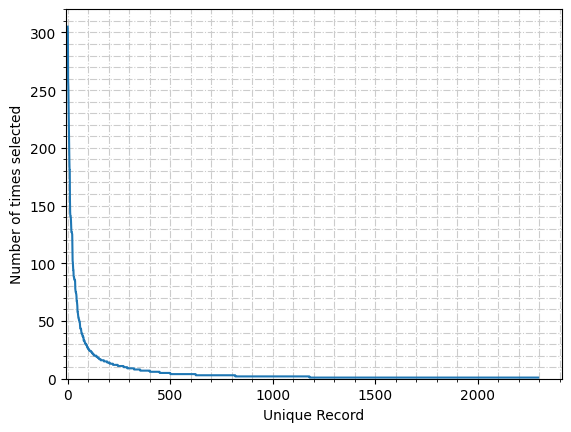

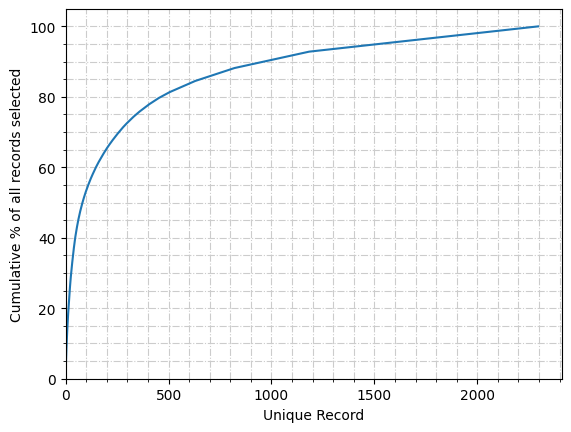

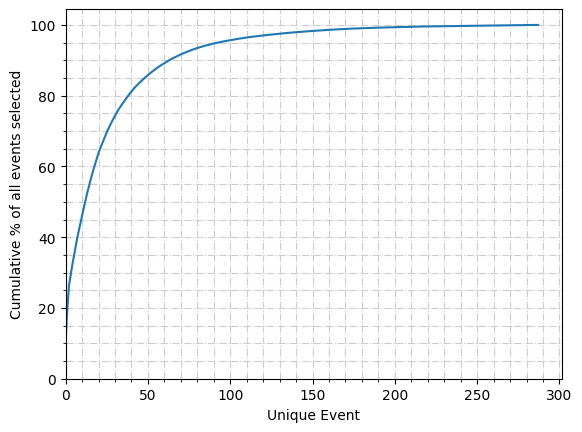

In [6]:
fig, ax3 = plt.subplots()
ax3.plot(recs_and_events["count"].to_numpy())
ax3.grid(True, which="both", ls="-.", color="0.8")
ax3.minorticks_on()
ax3.set_xlabel("Unique Record")
ax3.set_ylabel("Number of times selected")
ax3.set_ylim(0)
ax3.set_xlim(-10)

fig, ax1 = plt.subplots()
ax1.plot(recs_and_events["cum_%"].to_numpy())
ax1.grid(True, which="both", ls="-.", color="0.8")
ax1.minorticks_on()
ax1.set_xlabel("Unique Record")
ax1.set_ylabel("Cumulative % of all records selected")
ax1.set_ylim(0)
ax1.set_xlim(0)

fig, ax2 = plt.subplots()
ax2.plot(events["cum_%"].to_numpy())
ax2.grid(True, which="both", ls="-.", color="0.8")
ax2.minorticks_on()
ax2.set_xlabel("Unique Event")
ax2.set_ylabel("Cumulative % of all events selected")
ax2.set_ylim(0)
ax2.set_xlim(0)


## Records to download / convert

In [7]:
cols_to_keep = [("metadata", "event_id"), ("metadata", "station_code"), ("metadata", "location_code")]
unique_esm_records = all_recs[all_recs[("metadata", "database")] == "ESM"]\
                     .drop_duplicates(subset=cols_to_keep)
unique_esm_records = unique_esm_records[cols_to_keep].reset_index(drop=True)
esm_records_selected = unique_esm_records
esm_records_selected.to_csv(esm_records_selected_fp, index=False)
write_manifest(esm_records_selected_fp, csv_provenance)

WindowsPath('C:/Users/clemettn/Documents/phd/data_processed/06_gm_selection/AvgSA_03_summary_esm_records_selected.csv.manifest.json')

In [8]:
# For the NGASub records we need the NGAsubRSN for each combination of event_id and station_code
NGASub_records = all_recs[all_recs[("metadata", "database")] == "NGASub"]
unique_NGASub_id_counts = NGASub_records.groupby(
    [("metadata", "event_id"), ("metadata", "station_code")]).size().sort_values(ascending=False)
unique_NGASub_id_counts = unique_NGASub_id_counts.rename("count")

# load the NGASub database
ngasub_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"
ngasub_db = pd.read_csv(ngasub_fp, header=0, encoding="cp1252", dtype=str)
new_index = list(ngasub_db[["NGAsubEQID", "NGAsubSSN"]].itertuples(index=False, name=None))
ngasub_db.index = new_index
ngasub_db = ngasub_db["NGAsubRSN"]

# RSNs to download
rsns_selected = ngasub_db.loc[unique_NGASub_id_counts.index]
rsns_selected = pd.concat([rsns_selected, unique_NGASub_id_counts], axis=1)
rsns_selected.to_csv(ngasub_records_selected_fp, index=False)
write_manifest(ngasub_records_selected_fp, csv_provenance)

WindowsPath('C:/Users/clemettn/Documents/phd/data_processed/06_gm_selection/AvgSA_03_summary_ngasub_records_selected.csv.manifest.json')

In [9]:
# Per-campaign record-conversion list (record_identifier, component, database)
# for the AT2/HDF5 -> JSON converters. Combined across campaigns in
# wp1pt3pt8i-organise_records_to_download.
records_to_convert = (
    all_recs["metadata"][["record_identifier", "component", "database"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
records_to_convert.to_csv(records_to_convert_fp, index=False)
write_manifest(records_to_convert_fp, csv_provenance)

WindowsPath('C:/Users/clemettn/Documents/phd/data_processed/06_gm_selection/AvgSA_03_records_to_convert.csv.manifest.json')